# Figure 1: neural OT on the bimodal Gaussian target

This notebook trains `NeuralOptimalTransportPredictor` on the synthetic bimodal Gaussian dataset used by the figure-1 experiments, then plots the neural pushforward and pullback sets.

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import torch

from matplotlib.patches import Circle, Patch, Polygon
from matplotlib.path import Path as MplPath
from scipy.stats import chi2

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent.parent

src_path = str(repo_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from configs.datasets.synthetic.bimodal_gaussian import (
    BimodalGaussianDatasetConfig,
)
from configs.predictors.transport.neural_optimal_transport import (
    NeuralOptimalTransportPredictorConfig,
)
from configs.trainers.transport.neural_optimal_transport import (
    NeuralOptimalTransportTrainerConfig,
)
from data.datasets.synthetic.bimodal_gaussian import BimodalGaussianDataset
from data.loaders import make_xy_dataloader
from predictors.transport.neural_optimal_transport import (
    NeuralOptimalTransportPredictor,
)
from trainers.transport.neural_optimal_transport import NeuralQuantileTrainer

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [2]:
seed = 7
torch.manual_seed(seed)

device = "cpu"
dtype = "float32"

n_train = 4_096
n_calibration = 1_024
n_test = 1_024
batch_size = 256

hidden_dim = 128
num_hidden_layers = 3
epochs = 25
warmup_iterations = 1
c_transform_max_iter = 50


In [3]:
dataset_config = BimodalGaussianDatasetConfig(
    n_train=n_train,
    n_calibration=n_calibration,
    n_test=n_test,
    x_dim=1,
    y_dim=2,
    mode_offset=1.0,
    noise_scale=1.0,
    seed=seed,
    device=device,
    dtype=dtype,
)

dataset = BimodalGaussianDataset(dataset_config)
splits = dataset.get_splits()

train_dataloader = make_xy_dataloader(
    data=splits.train,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

print("train x/y:", splits.train.x.shape, splits.train.y.shape)
print("calibration x/y:", splits.calibration.x.shape, splits.calibration.y.shape)
print("test x/y:", splits.test.x.shape, splits.test.y.shape)
print("target modes:", dataset.modes)


train x/y: torch.Size([4096, 1]) torch.Size([4096, 2])
calibration x/y: torch.Size([1024, 1]) torch.Size([1024, 2])
test x/y: torch.Size([1024, 1]) torch.Size([1024, 2])
target modes: tensor([[-1.,  0.],
        [ 1.,  0.]])


In [4]:
predictor_config = NeuralOptimalTransportPredictorConfig(
    x_dim=dataset.x_dim,
    y_dim=dataset.y_dim,
    hidden_dim=hidden_dim,
    num_hidden_layers=num_hidden_layers,
    potential_type="u",
    c_transform_lr=0.25,
    c_transform_max_iter=c_transform_max_iter,
    seed=seed,
    device=device,
    dtype=dtype,
)

trainer_config = NeuralOptimalTransportTrainerConfig(
    epochs=epochs,
    learning_rate=1e-3,
    weight_decay=1e-4,
    warmup_iterations=warmup_iterations,
    grad_clip_norm=1.0,
    use_cosine_scheduler=True,
    verbose=True,
)

predictor = NeuralOptimalTransportPredictor(predictor_config)
trainer = NeuralQuantileTrainer(trainer_config)


In [5]:
predictor = trainer.fit(
    predictor=predictor,
    dataloader=train_dataloader,
)

trainer.training_history[-5:]

Warmup 1 | Loss 1.1535: 100%|██████████| 1/1 [00:00<00:00,  7.20it/s]
Epoch 25 | Potential loss 2.0510: 100%|██████████| 25/25 [00:31<00:00,  1.24s/it]


[{'epoch': 21,
  'potential_loss': 2.028650999069214,
  'epoch_time': 1.1454102920251898,
  'learning_rate': 6.184665997806823e-05},
 {'epoch': 22,
  'potential_loss': 2.0321340560913086,
  'epoch_time': 1.1692926249816082,
  'learning_rate': 3.511175705587433e-05},
 {'epoch': 23,
  'potential_loss': 2.0483481884002686,
  'epoch_time': 1.170128499972634,
  'learning_rate': 1.5708419435684524e-05},
 {'epoch': 24,
  'potential_loss': 2.027096748352051,
  'epoch_time': 1.159789290977642,
  'learning_rate': 3.942649342761118e-06},
 {'epoch': 25,
  'potential_loss': 2.0510013103485107,
  'epoch_time': 1.1105618329602294,
  'learning_rate': 0.0}]

In [6]:
predictor.eval()

n_eval = 2_048
x_eval = dataset.sample_x(n_eval)
u_eval = dataset.sample_source(n_eval)
y_generated = predictor.pushforward(x=x_eval, u=u_eval)

z_test = predictor.multivariate_score(
    x=splits.test.x[:n_eval],
    y=splits.test.y[:n_eval],
)

summary = {
    "generated_mean": y_generated.mean(dim=0).detach().cpu(),
    "generated_std": y_generated.std(dim=0).detach().cpu(),
    "target_mean": splits.test.y[:n_eval].mean(dim=0).detach().cpu(),
    "target_std": splits.test.y[:n_eval].std(dim=0).detach().cpu(),
    "test_score_mean": z_test.mean(dim=0).detach().cpu(),
    "test_score_std": z_test.std(dim=0).detach().cpu(),
}

summary


{'generated_mean': tensor([-0.0436, -0.0319]),
 'generated_std': tensor([1.4139, 1.0004]),
 'target_mean': tensor([-0.0307, -0.0446]),
 'target_std': tensor([1.4498, 0.9821]),
 'test_score_mean': tensor([-0.0335, -0.0524]),
 'test_score_std': tensor([1.0306, 0.9927])}

coverage_mass = 0.250
r_source from chi2 quantile = 0.7585
r_hdr from MC calibration = 0.6944
MC mass at r_hdr = 0.2500
HDR target-space volume estimate = 3.0
Neural OT target-space volume estimate = 2.6


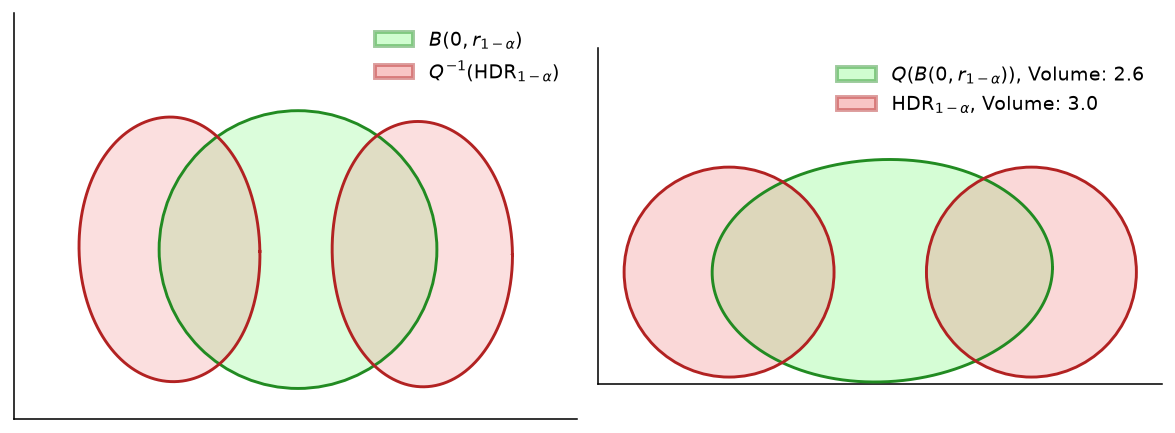

In [19]:
predictor.eval()

# The plotted sets use the conventional 1 - alpha coverage level,
# matching figure_1_discrete_ot.
alpha = 0.75
coverage_mass = 1.0 - alpha

n_radius_mc = 1_000_000
n_boundary_points = 720
n_volume_mc = 500_000
plot_batch_size = 256

side_margin_fraction = 0.05
bottom_margin_fraction = 0.01
top_margin_fraction = 0.25

output_path = Path("../figures/figure_1.pdf")
output_path.parent.mkdir(parents=True, exist_ok=True)

def calibrate_hdr_radius(mass, n_mc):
    y_mc = dataset.sample_target(n_mc)
    distances = torch.linalg.norm(
        y_mc[:, None, :] - dataset.modes[None, :, :],
        dim=-1,
    ).min(dim=1).values

    rank = int(np.ceil(mass * distances.numel()))
    rank = max(1, min(rank, distances.numel()))
    radius = torch.kthvalue(distances, rank).values
    empirical_mass = (distances <= radius).to(torch.float32).mean()
    return float(radius.detach().cpu()), float(empirical_mass.detach().cpu())


def neural_pushforward(u, batch_size=plot_batch_size):
    mapped = []
    for start in range(0, u.shape[0], batch_size):
        u_batch = u[start:start + batch_size]
        x_batch = dataset.sample_x(u_batch.shape[0])
        mapped.append(predictor.pushforward(x=x_batch, u=u_batch).detach().cpu())
    return torch.cat(mapped, dim=0)


def neural_pullback(y, batch_size=plot_batch_size):
    mapped = []
    for start in range(0, y.shape[0], batch_size):
        y_batch = y[start:start + batch_size]
        x_batch = dataset.sample_x(y_batch.shape[0])
        mapped.append(predictor.pullback(x=x_batch, y=y_batch).detach().cpu())
    return torch.cat(mapped, dim=0)


def circle_boundary(center, radius, n_points):
    theta = np.linspace(0.0, 2.0 * np.pi, n_points, endpoint=True)
    boundary = np.column_stack([np.cos(theta), np.sin(theta)])
    boundary = np.asarray(center, dtype=float) + radius * boundary
    return torch.as_tensor(boundary, device=dataset.device, dtype=dataset.dtype)


def close_contour(contour):
    if np.allclose(contour[0], contour[-1]):
        return contour
    return np.vstack([contour, contour[0]])


def contour_bounds(
    contours,
    side_margin=side_margin_fraction,
    bottom_margin=bottom_margin_fraction,
    top_margin=top_margin_fraction,
):
    points = np.vstack([np.asarray(contour) for contour in contours])
    xmin, ymin = points.min(axis=0)
    xmax, ymax = points.max(axis=0)
    width = max(xmax - xmin, 1e-12)
    height = max(ymax - ymin, 1e-12)

    return (
        xmin - side_margin * width,
        xmax + side_margin * width,
        ymin - bottom_margin * height,
        ymax + top_margin * height,
    )


def target_volume_bounds(contour, modes, hdr_radius, padding=0.1):
    hdr_lower = (modes - hdr_radius).min(axis=0)
    hdr_upper = (modes + hdr_radius).max(axis=0)
    lower = np.minimum(contour.min(axis=0), hdr_lower) - padding
    upper = np.maximum(contour.max(axis=0), hdr_upper) + padding
    return (lower[0], upper[0], lower[1], upper[1])


def estimate_target_volumes(ot_contour, modes, hdr_radius, n_mc, rng):
    bounds = target_volume_bounds(ot_contour, modes, hdr_radius)
    xmin, xmax, ymin, ymax = bounds
    samples = rng.uniform(
        low=np.array([xmin, ymin]),
        high=np.array([xmax, ymax]),
        size=(n_mc, 2),
    )
    box_area = (xmax - xmin) * (ymax - ymin)

    hdr_distances = np.linalg.norm(
        samples[:, None, :] - modes[None, :, :],
        axis=-1,
    )
    hdr_mask = hdr_distances.min(axis=1) <= hdr_radius

    ot_path = MplPath(close_contour(ot_contour))
    ot_mask = ot_path.contains_points(samples)

    return float(box_area * hdr_mask.mean()), float(box_area * ot_mask.mean())


modes = dataset.modes.detach().cpu().numpy()
r_source = float(np.sqrt(chi2.ppf(coverage_mass, df=dataset.y_dim)))
r_hdr, hdr_radius_mc_mass = calibrate_hdr_radius(coverage_mass, n_radius_mc)

source_ball_boundary = circle_boundary(
    center=(0.0, 0.0),
    radius=r_source,
    n_points=n_boundary_points,
)
source_ball_contour = source_ball_boundary.detach().cpu().numpy()
pushforward_ball_contour = close_contour(
    neural_pushforward(source_ball_boundary).numpy()
)

volume_rng = np.random.default_rng(seed)
hdr_volume, neural_ot_volume = estimate_target_volumes(
    ot_contour=pushforward_ball_contour,
    modes=modes,
    hdr_radius=r_hdr,
    n_mc=n_volume_mc,
    rng=volume_rng,
)

target_hdr_contours = []
pullback_hdr_contours = []
for mode in modes:
    target_hdr_boundary = circle_boundary(
        center=mode,
        radius=r_hdr,
        n_points=n_boundary_points,
    )
    target_hdr_contours.append(target_hdr_boundary.detach().cpu().numpy())
    pullback_hdr_contours.append(
        close_contour(neural_pullback(target_hdr_boundary).numpy())
    )

source_bounds = contour_bounds(
    [source_ball_contour, *pullback_hdr_contours],
    side_margin = 0.15,
    bottom_margin = 0.11,
    top_margin = 0.35
)
target_bounds = contour_bounds(
    [pushforward_ball_contour, *target_hdr_contours],
    side_margin = 0.05, 
    bottom_margin = 0.01,
    top_margin=0.5
)

print(f"coverage_mass = {coverage_mass:.3f}")
print(f"r_source from chi2 quantile = {r_source:.4f}")
print(f"r_hdr from MC calibration = {r_hdr:.4f}")
print(f"MC mass at r_hdr = {hdr_radius_mc_mass:.4f}")
print(f"HDR target-space volume estimate = {hdr_volume:.1f}")
print(f"Neural OT target-space volume estimate = {neural_ot_volume:.1f}")

fig, (ax_source, ax_target) = plt.subplots(
    1,
    2,
    figsize=(8.5, 4.5),
    constrained_layout=False,
)
fig.subplots_adjust(
    left=0.07,
    right=0.98,
    bottom=0.15,
    top=0.82,
    wspace=0.28,
)
title_y = 1.03

for ax in (ax_source, ax_target):
    # Remove ticks
    ax.set_xticks([])
    ax.set_yticks([])
    # ax.set_frame_on(False)
    # ax.tick_params(
    #     left=False,
    #     right=False,
    #     bottom=False,
    #     top=False,
    #     labelleft=False,
    #     labelbottom=False,
    # )

    # # Make all four borders visible
    # for side in ("left", "right", "bottom", "top"):
    #     ax.spines[side].set_visible(True)
    #     ax.spines[side].set_color("#C8C8C8")
    #     ax.spines[side].set_linewidth(0.7)

ax_source.add_patch(
    Circle(
        (0.0, 0.0),
        r_source,
        fill=True,
        facecolor="palegreen",
        edgecolor="none",
        alpha=0.35,
        zorder=1,
    )
)
ax_source.add_patch(
    Circle(
        (0.0, 0.0),
        r_source,
        fill=False,
        edgecolor="forestgreen",
    linewidth=1.5,
        zorder=4,
    )
)
for contour in pullback_hdr_contours:
    ax_source.add_patch(
        Polygon(
            contour,
            closed=True,
            facecolor="lightcoral",
            edgecolor="none",
            alpha=0.25,
            zorder=2,
        )
    )
    ax_source.plot(
        contour[:, 0],
        contour[:, 1],
        color="firebrick",
    linewidth=1.5,
        zorder=5,
    )
# ax_source.set_title("Source standard normal distribution", y=title_y, fontsize=11)
# ax_source.set_xlabel(r"$u_1$")
# ax_source.set_ylabel(r"$u_2$")
ax_source.set_xlim(source_bounds[0], source_bounds[1])
ax_source.set_ylim(source_bounds[2], source_bounds[3])
ax_source.set_aspect("equal", adjustable="box")
ax_source.set_anchor("C")
ax_source.legend(
    handles=[
        Patch(facecolor="palegreen", edgecolor="forestgreen", linewidth=2.0,
              alpha=0.45, label=r"$B(0, r_{1-\alpha})$"),
        Patch(facecolor="lightcoral", edgecolor="firebrick", linewidth=2.0,
              alpha=0.45, label=r"$Q^{-1}($HDR$_{1-\alpha})$"),
    ],
    loc="upper right",
    frameon=False,
)

ax_target.add_patch(
    Polygon(
        pushforward_ball_contour,
        closed=True,
        facecolor="palegreen",
        edgecolor="none",
        alpha=0.40,
        zorder=1,
    )
)
ax_target.plot(
    pushforward_ball_contour[:, 0],
    pushforward_ball_contour[:, 1],
    color="forestgreen",
    linewidth=1.5,
    zorder=5,
)
for mode in modes:
    ax_target.add_patch(
        Circle(
            tuple(mode),
            r_hdr,
            fill=True,
            facecolor="lightcoral",
            edgecolor="none",
            alpha=0.30,
            zorder=2,
        )
    )
    ax_target.add_patch(
        Circle(
            tuple(mode),
            r_hdr,
            fill=False,
            edgecolor="firebrick",
            linewidth=1.5,
            zorder=6,
        )
    )
# ax_target.set_title("Target bimodal Gaussian distribution", y=title_y, fontsize=11)
# ax_target.set_xlabel(r"$y_1$")
# ax_target.set_ylabel(r"$y_2$")
ax_target.set_xlim(target_bounds[0], target_bounds[1])
ax_target.set_ylim(target_bounds[2], target_bounds[3])
ax_target.set_aspect("equal", adjustable="box")
ax_target.set_anchor("C")
ax_target.legend(
    handles=[
        Patch(facecolor="palegreen", edgecolor="forestgreen", linewidth=2.0,
              alpha=0.45,
              label=rf"$Q(B(0, r_{{1-\alpha}}))$, Volume: {neural_ot_volume:.1f}"),
        Patch(facecolor="lightcoral", edgecolor="firebrick", linewidth=2.0,
              alpha=0.45,
              label=rf"HDR$_{{1-\alpha}}$, Volume: {hdr_volume:.1f}"),
    ],
    loc="upper right",
    frameon=False,
)

# fig.suptitle(
#     r"$Q$ - Brenier map , $\alpha$=" + f"{alpha:.2f}",
#     y=1.,
#     fontsize=13
# )
fig.align_xlabels([ax_source, ax_target])
fig.align_ylabels([ax_source, ax_target])
fig.tight_layout()
fig.savefig(
    output_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02,
    metadata={"Creator": "Matplotlib"},
)

plt.show()